###### Imports

In [1]:
import pandas as pd
import matplotlib.pylab as plt
import seaborn as sns
import numpy as np

###### Load data

In [2]:
df = pd.read_csv("data/iris.csv").drop_duplicates().dropna()

### Preparing data

In [3]:
df.shape

(147, 5)

In [4]:
df.sample(5)

,sepal_length,sepal_width,petal_length,petal_width,species
33,5.5,4.2,1.4,0.2,setosa
75,6.6,3.0,4.4,1.4,versicolor
0,5.1,3.5,1.4,0.2,setosa
6,4.6,3.4,1.4,0.3,setosa
18,5.7,3.8,1.7,0.3,setosa


In [5]:
print(df["species"].unique())

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [6]:
print(df.dtypes)

sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

###### Onehot encode species so it can be processed

In [7]:
df = pd.concat([df, pd.get_dummies(df["species"])], axis=1)
df = df.drop(columns=["species", "setosa", "versicolor"])

### Perceptron from scratch

In [8]:
class Perceptron:
    def __init__(self, inputs=4, learning_rate=0.01):

        self.lr = learning_rate
        self.weights = np.zeros(inputs)
        self.bias = 0.0

    def activate(self, X: np.ndarray) -> int:
        guess = np.dot(self.weights, X) + self.bias

        return 1 if guess > 0 else 0

    def train(self, X: np.ndarray, y: int) -> int:
        guess = self.activate(X)

        error = y - guess

        self.weights += self.lr * error * X
        self.bias += self.lr * error

        return error

In [9]:
P = Perceptron()
nums = df.shape[0]
X_data = df[["sepal_length", "sepal_width", "petal_length", "petal_width"]].values
y_data = df["virginica"].values

In [10]:
epochs = 1000
for epoch in range(epochs):
    total_error = 0
    for i in range(nums):
        error = P.train(X_data[i], y_data[i])
        total_error += abs(error)

    # Stops if no error was made, wont happen for this dataset
    if total_error == 0:
        print(f"Converged early at epoch {epoch}!")
        break

###### Get Predictions

In [11]:
df["predicted_target"] = [P.activate(x) for x in X_data]
df["predicted_species"] = df["predicted_target"]

###### Compare Predictions visually using scatterplot

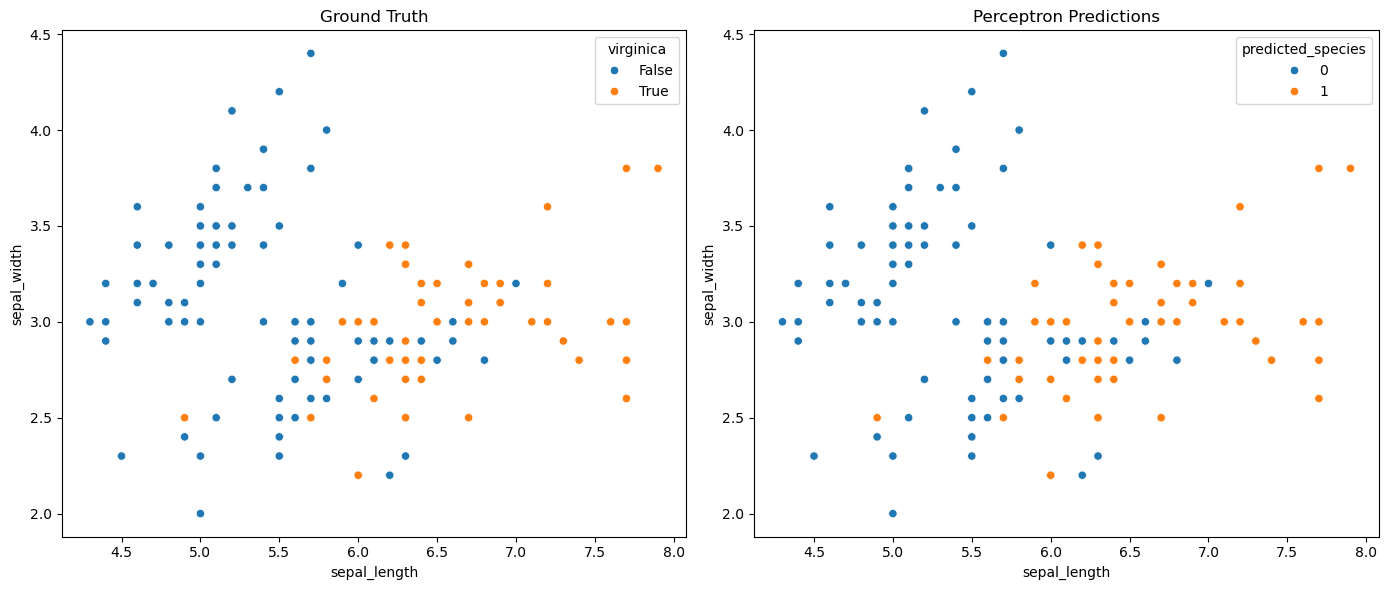

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(ax=axes[0], x="sepal_length", y="sepal_width", data=df, hue="virginica")
axes[0].set_title("Ground Truth")

sns.scatterplot(
    ax=axes[1], x="sepal_length", y="sepal_width", data=df, hue="predicted_species"
)
axes[1].set_title("Perceptron Predictions")

plt.tight_layout()
plt.show()